In [25]:
print(df.columns)

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='object')


In [26]:
Q1 = df['quantity'].quantile(0.25)
Q3 = df['quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['quantity'] < lower) |
    (df['quantity'] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 26294


In [27]:
normal_count = len(df) - len(outliers)

print("Normal Values:", normal_count)
print("Outliers:", len(outliers))

Normal Values: 374622
Outliers: 26294


In [28]:
print(df.shape)

(400916, 8)


In [29]:
Q1 = df['quantity'].quantile(0.25)
Q3 = df['quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['quantity'] < lower) |
    (df['quantity'] > upper)
]

normal = df[
    (df['quantity'] >= lower) &
    (df['quantity'] <= upper)
]

print("Total:", len(df))
print("Outliers:", len(outliers))
print("Normal:", len(normal))

Total: 400916
Outliers: 26294
Normal: 374622


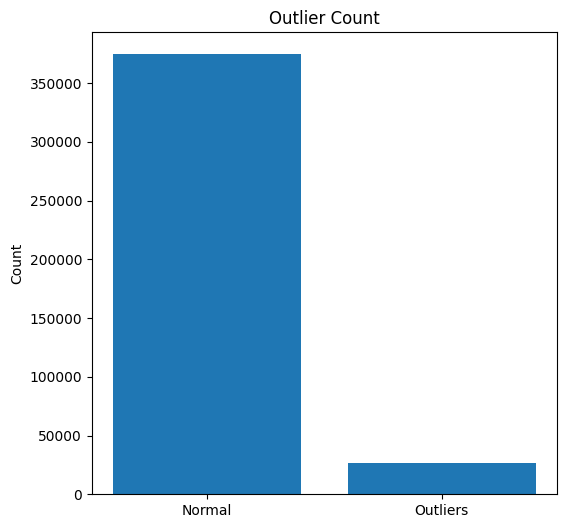

In [30]:
import matplotlib.pyplot as plt

labels = ['Normal', 'Outliers']
values = [normal_count, len(outliers)]

plt.figure(figsize=(6,6))

plt.bar(labels, values)

plt.title("Outlier Count")

plt.ylabel("Count")

plt.show()

In [31]:
df['TotalSales'] = df['quantity'] * df['price']

In [32]:
df['Year'] = df['invoicedate'].dt.year # yearly wise sales extract (output like 2020,2021 like)
df['Month'] = df['invoicedate'].dt.month #monly wise(jan,feb) know which month has high sales
df['Day'] = df['invoicedate'].dt.day #day wise inwhich day has high sale and low sales
df['Weekday'] = df['invoicedate'].dt.day_name()
df['WeekOfYear'] = df['invoicedate'].dt.isocalendar().week #1-52 weekly seasonality,festival weeks,holiday spikes
df['Quarter'] = df['invoicedate'].dt.quarter #quarterly sales 
df['Hour'] = df['invoicedate'].dt.hour # hourly sales

In [33]:
import pandas as pd

snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1) #Gets latest date in dataset. then adds 1

rfm = df.groupby('customer_id').agg({ #Combines all transactions customer-wise.
    'invoicedate': lambda x: (snapshot_date - x.max()).days, #days since last purchase
    'invoice': 'nunique',#Counts unique invoices.
    'TotalSales': 'sum' #Calculates total spending.
}) 

rfm.columns = ['Recency', 'Frequency', 'Monetary'] #Recency-how recently customer bought
#Frequency-how often customer buys
#Monetary-how much customer spends
#helps to Convert transaction data into customer behavior intelligence.
rfm.reset_index(inplace=True)


In [34]:
daily_sales = df.groupby('invoicedate')['TotalSales'].sum() #Converts transaction data into time-series data.
print(daily_sales)
daily_sales = daily_sales.reset_index() 
print(daily_sales)
daily_sales['lag_1'] = daily_sales['TotalSales'].shift(1) #Adds previous day's sales.
print(daily_sales)
daily_sales['lag_7'] = daily_sales['TotalSales'].shift(7) #Adds last week's same-day sales.
print(daily_sales)
daily_sales['lag_14'] = daily_sales['TotalSales'].shift(14) #Two weeks back sales.
print(daily_sales)

invoicedate
2009-12-01 07:45:00     505.30
2009-12-01 07:46:00     145.80
2009-12-01 09:06:00     630.33
2009-12-01 09:08:00     310.75
2009-12-01 09:24:00    2286.24
                        ...   
2010-12-09 18:58:00     298.95
2010-12-09 19:23:00     310.45
2010-12-09 19:28:00      93.45
2010-12-09 19:32:00     317.59
2010-12-09 20:01:00     300.64
Name: TotalSales, Length: 18008, dtype: float64
              invoicedate  TotalSales
0     2009-12-01 07:45:00      505.30
1     2009-12-01 07:46:00      145.80
2     2009-12-01 09:06:00      630.33
3     2009-12-01 09:08:00      310.75
4     2009-12-01 09:24:00     2286.24
...                   ...         ...
18003 2010-12-09 18:58:00      298.95
18004 2010-12-09 19:23:00      310.45
18005 2010-12-09 19:28:00       93.45
18006 2010-12-09 19:32:00      317.59
18007 2010-12-09 20:01:00      300.64

[18008 rows x 2 columns]
              invoicedate  TotalSales   lag_1
0     2009-12-01 07:45:00      505.30     NaN
1     2009-12-01 07:46:00

In [35]:
daily_sales['rolling_mean_7'] = (
    daily_sales['TotalSales']
    .rolling(window=7) #Calculates 7-day moving average.
    .mean()
)

daily_sales['rolling_std_7'] = (
    daily_sales['TotalSales']
    .rolling(window=7)
    .std() #Measures sales volatility.
)

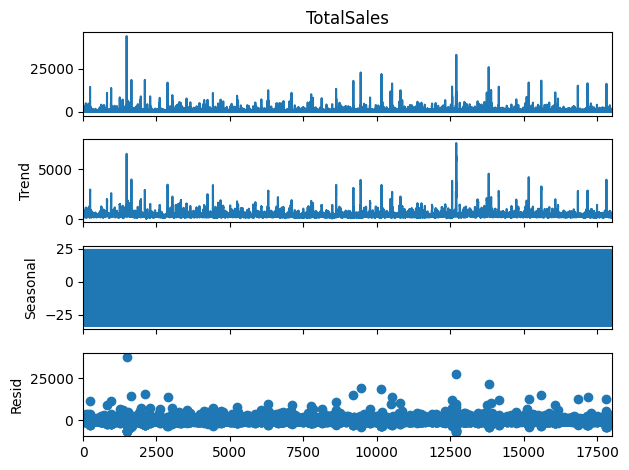

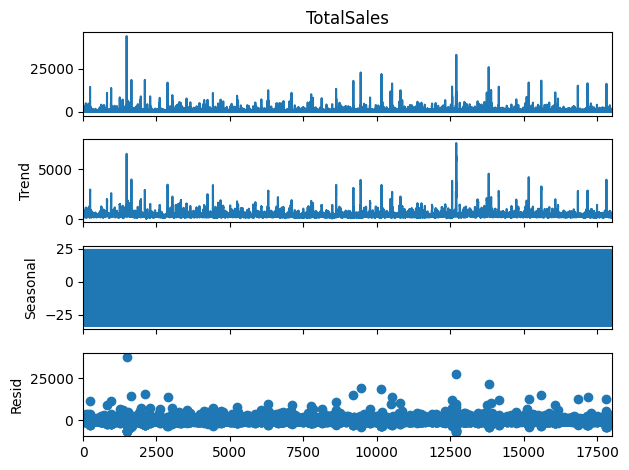

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

#| Component | Meaning            |
#| --------- | ------------------ |
#| Trend     | long-term movement | overall business growth/decline
#| Seasonal  | repeating pattern  | weekly repeating patterns
#| Residual  | random noise       | weekly seasonality


decomposition = seasonal_decompose(
    daily_sales['TotalSales'],
    model='additive',
    period=7
)

decomposition.plot()

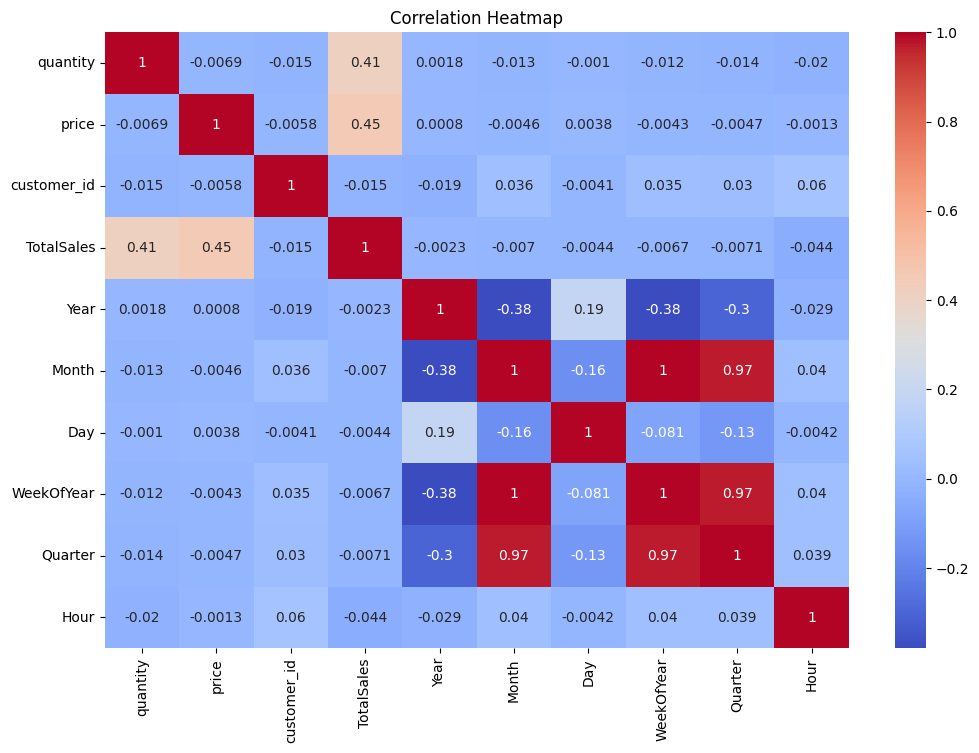

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [38]:
snapshot_date = df['invoicedate'].max()

customer_last_purchase = (
    df.groupby('customer_id')['invoicedate']
    .max()
)

customer_last_purchase = (
    snapshot_date - customer_last_purchase
).dt.days

rfm['Churn'] = (
    customer_last_purchase > 90
).astype(int)

In [39]:
product_sales = (
    df.groupby('stockcode')['TotalSales']
    .sum()
    .sort_values(ascending=False)
)

product_sales = product_sales.reset_index()

product_sales['CumulativePercent'] = (
    product_sales['TotalSales'].cumsum()
    / product_sales['TotalSales'].sum()
)

def abc_class(x):
    if x <= 0.7:
        return 'A'
    elif x <= 0.9:
        return 'B'
    return 'C'

product_sales['ABC_Class'] = (
    product_sales['CumulativePercent']
    .apply(abc_class)
)

In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales['TotalSales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -28.64760832414438
p-value: 0.0


Phase 2 — Baseline Machine Learning Models

In [41]:
# ============================================================
# STEP 1 — IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Churn prediction model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Customer segmentation
from sklearn.cluster import KMeans

# Forecasting model
from prophet import Prophet

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Importing plotly failed. Interactive plots will not work.


In [42]:
# Save cleaned transaction data
df.to_csv(
    'cleaned_retail.csv',
    index=False
)

# Save daily sales data
daily_sales.to_csv(
    'daily_sales.csv',
    index=False
)

# Save RFM customer data
rfm.to_csv(
    'rfm_customers.csv',
    index=False
)

print("Files Saved Successfully")

Files Saved Successfully


In [43]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'cleaned_retail.csv', 'customer_segments.csv', 'daily_sales.csv', 'Dataprocessing.ipynb', 'rfm_customers.csv', 'sales_forecast.csv', 'Untitled.ipynb']


In [44]:
# ============================================================
# STEP 2 — LOAD DATASETS
# ============================================================

# Load cleaned retail transaction dataset
# This contains processed transaction-level data

df = pd.read_csv('cleaned_retail.csv')

# Load daily sales dataset
# Used for forecasting

daily_sales = pd.read_csv('daily_sales.csv')

# Load RFM customer dataset
# Used for churn prediction and segmentation

rfm = pd.read_csv('rfm_customers.csv')

# Check first few rows
print(df.head())
print(daily_sales.head())
print(rfm.head())

   invoice stockcode                          description  quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           invoicedate  price  customer_id         country  TotalSales  Year  \
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom        83.4  2009   
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  2009   
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom        81.0  2009   
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom       100.8  2009   
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom        30.0  2009   

   Month  Day  Weekday  WeekOfYear  Quarter  Hour  
0     12    1  Tuesday          49      

In [45]:
# ============================================================
# STEP 3 — PREPARE FORECAST DATA
# ============================================================

# Prophet requires:
# ds -> date column
# y -> target column

forecast_df = daily_sales.copy()

# Select required columns
forecast_df = forecast_df[
    ['invoicedate', 'TotalSales']
]

# Rename columns for Prophet
forecast_df.columns = ['ds', 'y']

# Convert ds column to datetime
forecast_df['ds'] = pd.to_datetime(
    forecast_df['ds']
)

# Check prepared data
print(forecast_df.head())

                   ds        y
0 2009-12-01 07:45:00   505.30
1 2009-12-01 07:46:00   145.80
2 2009-12-01 09:06:00   630.33
3 2009-12-01 09:08:00   310.75
4 2009-12-01 09:24:00  2286.24


In [46]:
 #============================================================
# STEP 4 — CREATE AND TRAIN PROPHET MODEL
# ============================================================

# Create Prophet model
model = Prophet()
#
# Train model using historical sales data
model.fit(forecast_df)

20:30:44 - cmdstanpy - INFO - Chain [1] start processing
20:30:53 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
# ============================================================
# STEP 5 — CREATE FUTURE DATES
# ============================================================

# Create future dataframe for next 30 days
future = model.make_future_dataframe(
    periods=30
)

# Check future dates
print(future.tail())

                       ds
18033 2011-01-04 20:01:00
18034 2011-01-05 20:01:00
18035 2011-01-06 20:01:00
18036 2011-01-07 20:01:00
18037 2011-01-08 20:01:00


In [48]:
# ============================================================
# STEP 6 — FORECAST FUTURE SALES
# ============================================================

# Predict future sales
forecast = model.predict(future)

# Show important forecast columns
print(
    forecast[
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ].tail()
)

                       ds        yhat   yhat_lower   yhat_upper
18033 2011-01-04 20:01:00  446.356854  -830.021970  1660.455570
18034 2011-01-05 20:01:00  393.643558  -896.176066  1577.670435
18035 2011-01-06 20:01:00  470.684907  -668.287322  1727.302055
18036 2011-01-07 20:01:00  341.418269  -899.551973  1563.134232
18037 2011-01-08 20:01:00  163.933619 -1093.521162  1333.194255


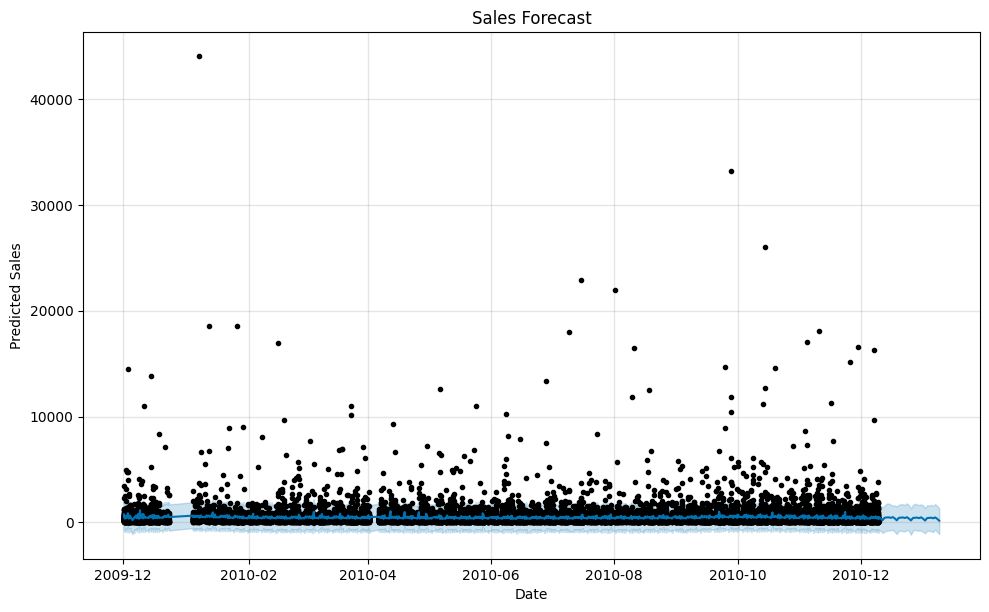

In [49]:
# ============================================================
# STEP 7 — VISUALIZE FORECAST
# ============================================================

# Plot forecast graph
model.plot(forecast)

plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')

plt.show()

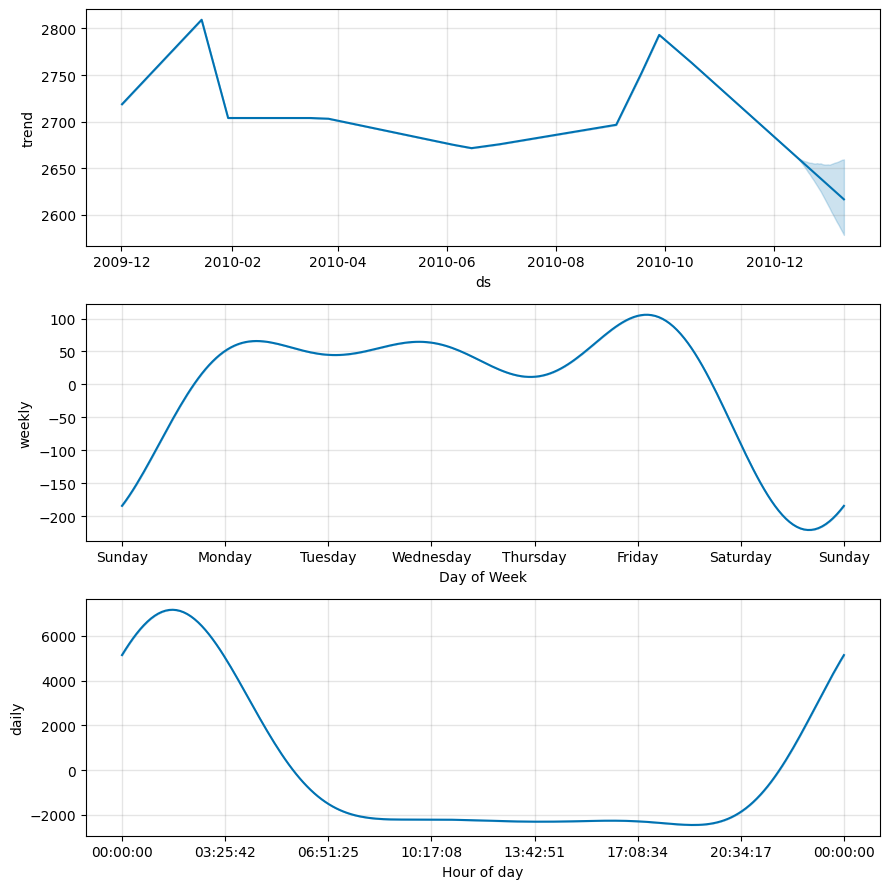

In [50]:
# ============================================================
# STEP 8 — VISUALIZE TREND & SEASONALITY
# ============================================================

# Plot trend and seasonality
model.plot_components(forecast)

plt.show()

In [51]:
# ============================================================
# STEP 9 — CREATE CHURN LABEL
# ============================================================

# Customers inactive for more than 90 days
# are considered churned customers

rfm['Churn'] = (
    rfm['Recency'] > 90
).astype(int)

# Check churn distribution
print(rfm['Churn'].value_counts())

Churn
0    2877
1    1435
Name: count, dtype: int64


In [52]:
# ============================================================
# STEP 10 — SELECT FEATURES AND TARGET
# ============================================================

# Features used for prediction
X = rfm[
    ['Recency', 'Frequency', 'Monetary']
]

# Target column
# 1 = churned customer
# 0 = active customer

y = rfm['Churn']

In [53]:
# ============================================================
# STEP 11 — SPLIT DATA INTO TRAIN AND TEST
# ============================================================

# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [54]:
# ============================================================
# STEP 12 — FEATURE SCALING
# ============================================================

# Scaling improves ML model performance

scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform testing data
X_test_scaled = scaler.transform(
    X_test
)

In [55]:
# ============================================================
# STEP 13 — TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

# Create Logistic Regression model
churn_model = LogisticRegression()

# Train model
churn_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [56]:
# ============================================================
# STEP 14 — PREDICT CUSTOMER CHURN
# ============================================================

# Predict churn on test data

y_pred = churn_model.predict(
    X_test_scaled
)

In [57]:
# ============================================================
# STEP 15 — EVALUATE CHURN MODEL
# ============================================================

# Calculate model accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print('Accuracy:', accuracy)

# Detailed classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9907300115874855
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       571
           1       1.00      0.97      0.99       292

    accuracy                           0.99       863
   macro avg       0.99      0.99      0.99       863
weighted avg       0.99      0.99      0.99       863



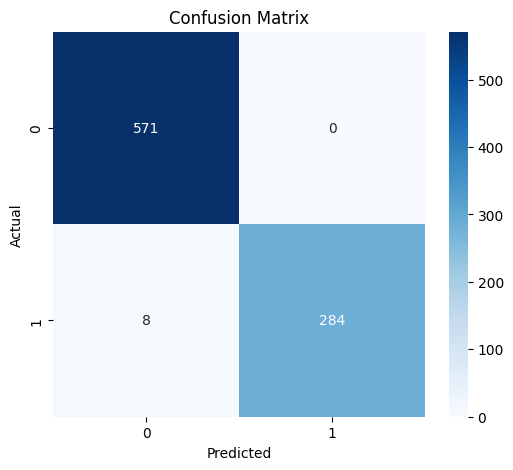

In [58]:
# ============================================================
# STEP 16 — CONFUSION MATRIX
# ============================================================

# Generate confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()